<a href="https://colab.research.google.com/github/Bienbaz/Feature-Engineering-NBA-Player-Longevity-Prediction/blob/main/nba_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings for clean output
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# Load the dataset
# Make sure 'nba-players.csv' is uploaded to your Colab environment
df = pd.read_csv('nba-players.csv')

# Display the first few rows
display(df.head())

# Verify the target variable distribution
print("\nTarget Variable Distribution (target_5yrs):")
print(df['target_5yrs'].value_counts(normalize=True) * 100)

,Unnamed: 0,name,gp,min,pts,fgm,fga,fg,3p_made,3pa,...,fta,ft,oreb,dreb,reb,ast,stl,blk,tov,target_5yrs
0,0,Brandon Ingram,36,27.4,7.4,2.6,7.6,34.7,0.5,2.1,...,2.3,69.9,0.7,3.4,4.1,1.9,0.4,0.4,1.3,0
1,1,Andrew Harrison,35,26.9,7.2,2.0,6.7,29.6,0.7,2.8,...,3.4,76.5,0.5,2.0,2.4,3.7,1.1,0.5,1.6,0
2,2,JaKarr Sampson,74,15.3,5.2,2.0,4.7,42.2,0.4,1.7,...,1.3,67.0,0.5,1.7,2.2,1.0,0.5,0.3,1.0,0
3,3,Malik Sealy,58,11.6,5.7,2.3,5.5,42.6,0.1,0.5,...,1.3,68.9,1.0,0.9,1.9,0.8,0.6,0.1,1.0,1
4,4,Matt Geiger,48,11.5,4.5,1.6,3.0,52.4,0.0,0.1,...,1.9,67.4,1.0,1.5,2.5,0.3,0.3,0.4,0.8,1



Target Variable Distribution (target_5yrs):
target_5yrs
1    62.014925
0    37.985075
Name: proportion, dtype: float64


In [5]:
# Drop the 'name' column if it exists in the dataset
if 'name' in df.columns:
    df = df.drop(columns=['name'])
    print("Dropped 'name' column.")

# Display current columns
print("Current features:", df.columns.tolist())

Dropped 'name' column.
Current features: ['Unnamed: 0', 'gp', 'min', 'pts', 'fgm', 'fga', 'fg', '3p_made', '3pa', '3p', 'ftm', 'fta', 'ft', 'oreb', 'dreb', 'reb', 'ast', 'stl', 'blk', 'tov', 'target_5yrs']


In [6]:
# Check for null values
print("Missing values before cleaning:\n", df.isnull().sum()[df.isnull().sum() > 0])

# Fill missing values with 0.0 (Assuming they are related to 0 attempts for percentages)
df = df.fillna(0.0)

# Verify cleaning
print("\nMissing values after cleaning:", df.isnull().sum().sum())

Missing values before cleaning:
 Series([], dtype: int64)

Missing values after cleaning: 0


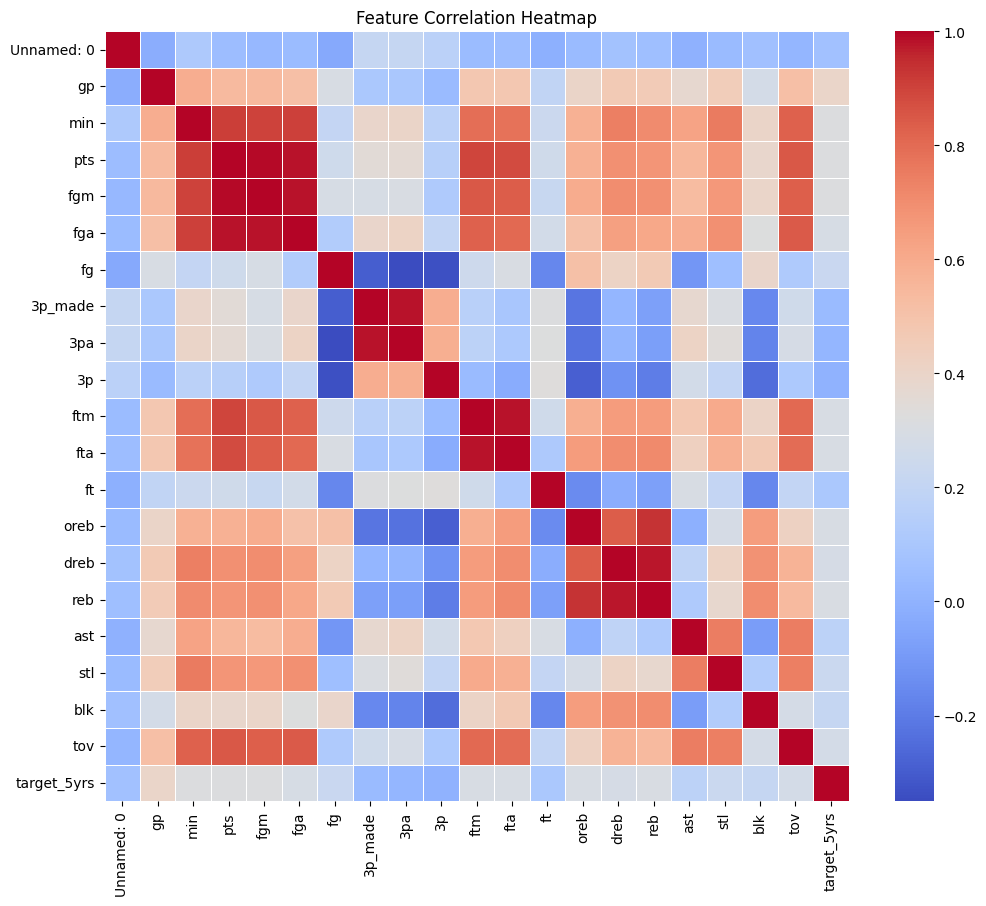


Dropped redundant columns to reduce multicollinearity: ['fgm', 'fga', '3pm', '3pa', 'ftm', 'fta']


In [7]:
# Plot a correlation heatmap
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

# Drop redundant features based on high correlation
# For example, Field Goals Made (fgm) is highly correlated with Points (pts).
# We keep percentages (fg%) and the final outcome (pts), but drop the raw attempts/makes.
redundant_cols = ['fgm', 'fga', '3pm', '3pa', 'ftm', 'fta']
df_reduced = df.drop(columns=[col for col in redundant_cols if col in df.columns])

print("\nDropped redundant columns to reduce multicollinearity:", redundant_cols)

In [8]:
# Create the composite metric
# We add a small number (0.1) to minutes to avoid division by zero errors
df_reduced['Efficiency_Per_Min'] = (df_reduced['pts'] + df_reduced['reb'] + df_reduced['ast']) / (df_reduced['min'] + 0.1)

# Display the new feature alongside the raw stats
display(df_reduced[['min', 'pts', 'reb', 'ast', 'Efficiency_Per_Min']].head())

,min,pts,reb,ast,Efficiency_Per_Min
0,27.4,7.4,4.1,1.9,0.487273
1,26.9,7.2,2.4,3.7,0.492593
2,15.3,5.2,2.2,1.0,0.545455
3,11.6,5.7,1.9,0.8,0.717949
4,11.5,4.5,2.5,0.3,0.629310


In [9]:
# Separate Features (X) and Target (y)
X = df_reduced.drop(columns=['target_5yrs'])
y = df_reduced['target_5yrs']

print(f"Final Feature Matrix (X) Shape: {X.shape}")
print(f"Target Array (y) Shape: {y.shape}")

# Save the engineered dataset to a new CSV for the modeling phase
df_reduced.to_csv('nba_engineered_features.csv', index=False)
print("Saved engineered dataset as 'nba_engineered_features.csv'")

Final Feature Matrix (X) Shape: (1340, 16)
Target Array (y) Shape: (1340,)
Saved engineered dataset as 'nba_engineered_features.csv'
